In [1]:
import pandas as pd

df = pd.read_csv('/content/data.csv')
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [3]:
df = pd.read_csv('data.csv')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print(df.shape)

(9994, 21)


In [5]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
df.duplicated().sum()


np.int64(0)

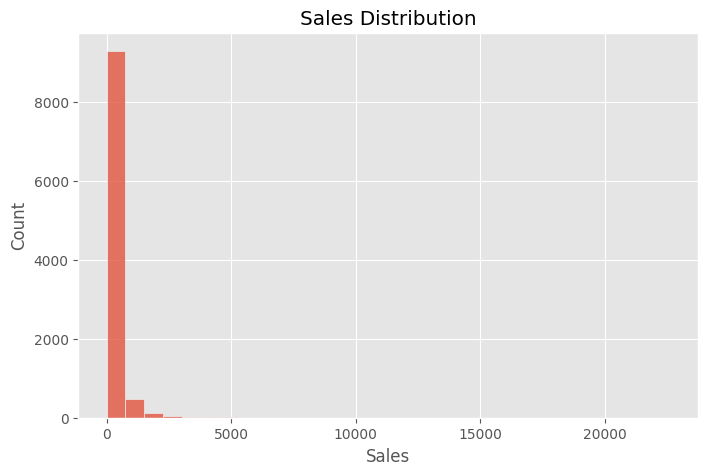

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['Sales'], bins=30)

plt.title('Sales Distribution')
plt.show()

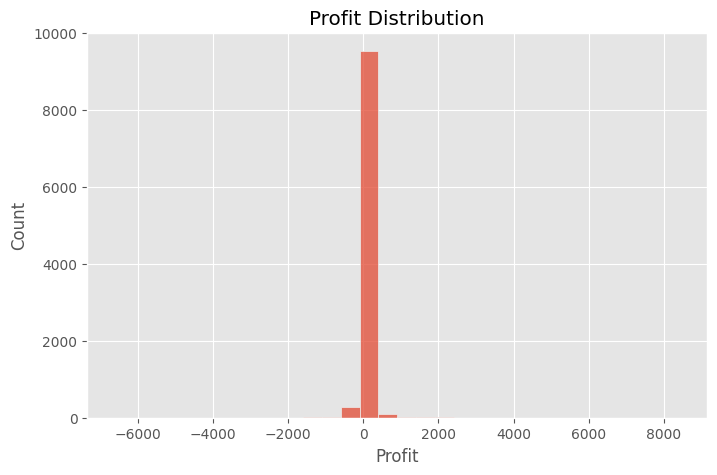

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['Profit'], bins=30)

plt.title('Profit Distribution')
plt.show()

In [10]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales

,Sales
Category,
Furniture,741999.7953
Office Supplies,719047.0320
Technology,836154.0330


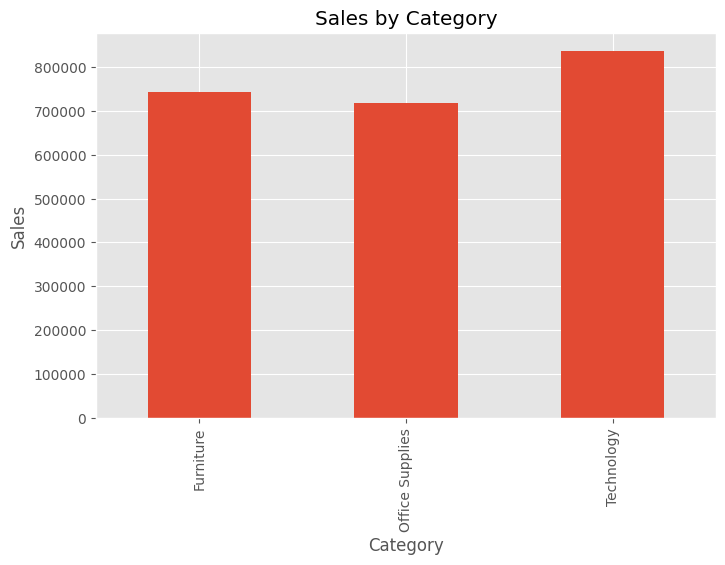

In [11]:
category_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Sales by Category')
plt.ylabel('Sales')
plt.show()

In [12]:
category_profit = df.groupby('Category')['Profit'].sum()

category_profit

,Profit
Category,
Furniture,18451.2728
Office Supplies,122490.8008
Technology,145454.9481


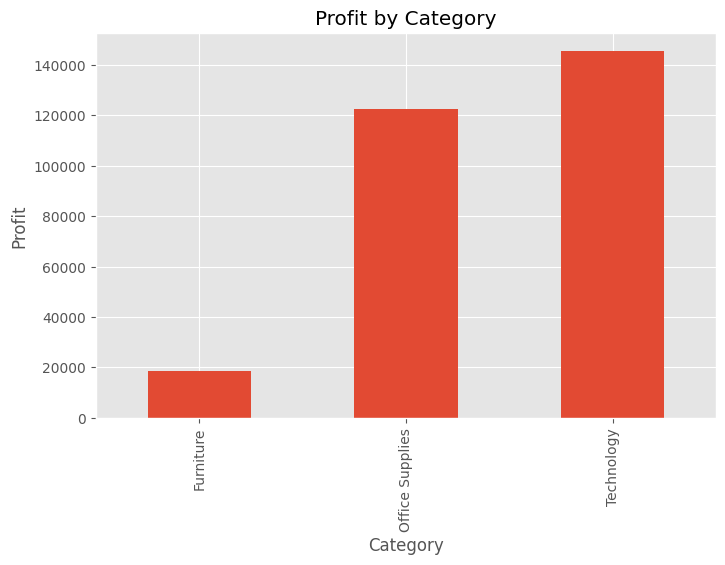

In [13]:
category_profit.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Profit by Category')
plt.ylabel('Profit')
plt.show()

In [14]:
top_sub = df.groupby(
    'Sub-Category'
)['Sales'].sum().sort_values(
    ascending=False
).head(10)

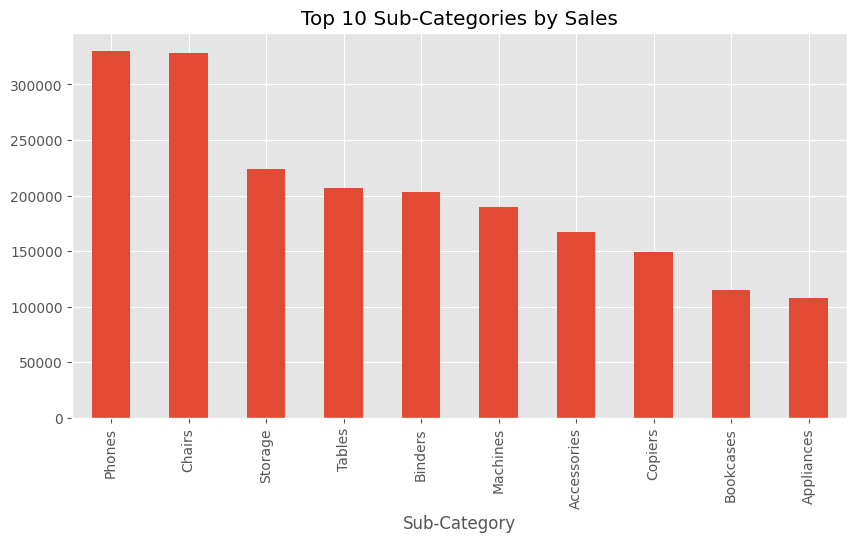

In [15]:
top_sub.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Sub-Categories by Sales')
plt.show()

In [16]:
region_sales = df.groupby(
    'Region'
)['Sales'].sum()

region_sales

,Sales
Region,
Central,501239.8908
East,678781.2400
South,391721.9050
West,725457.8245


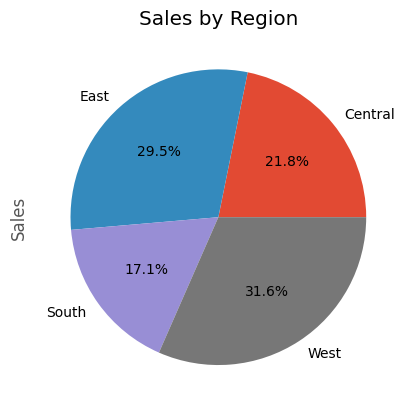

In [17]:
region_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Sales by Region')
plt.show()

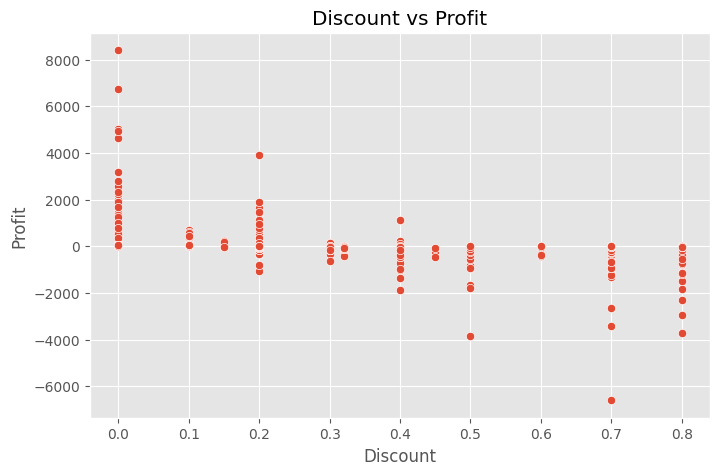

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Discount',
    y='Profit',
    data=df
)

plt.title(
    'Discount vs Profit'
)

plt.show()

In [19]:
num_cols = [
    'Sales',
    'Quantity',
    'Discount',
    'Profit'
]

corr = df[num_cols].corr()

corr

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


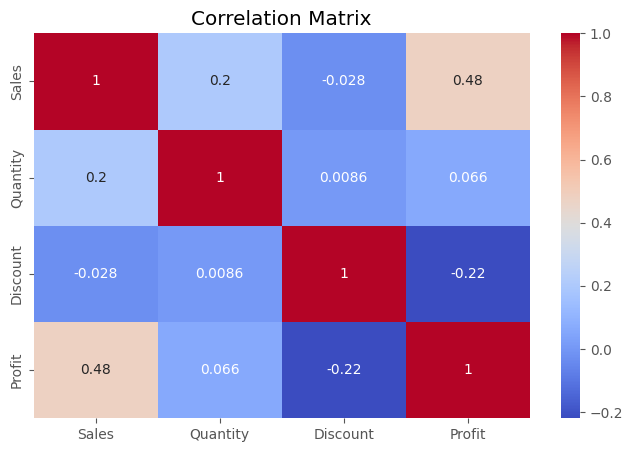

In [20]:
plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

In [21]:
top_profit = df.groupby(
    'Product Name'
)['Profit'].sum().sort_values(
    ascending=False
).head(10)

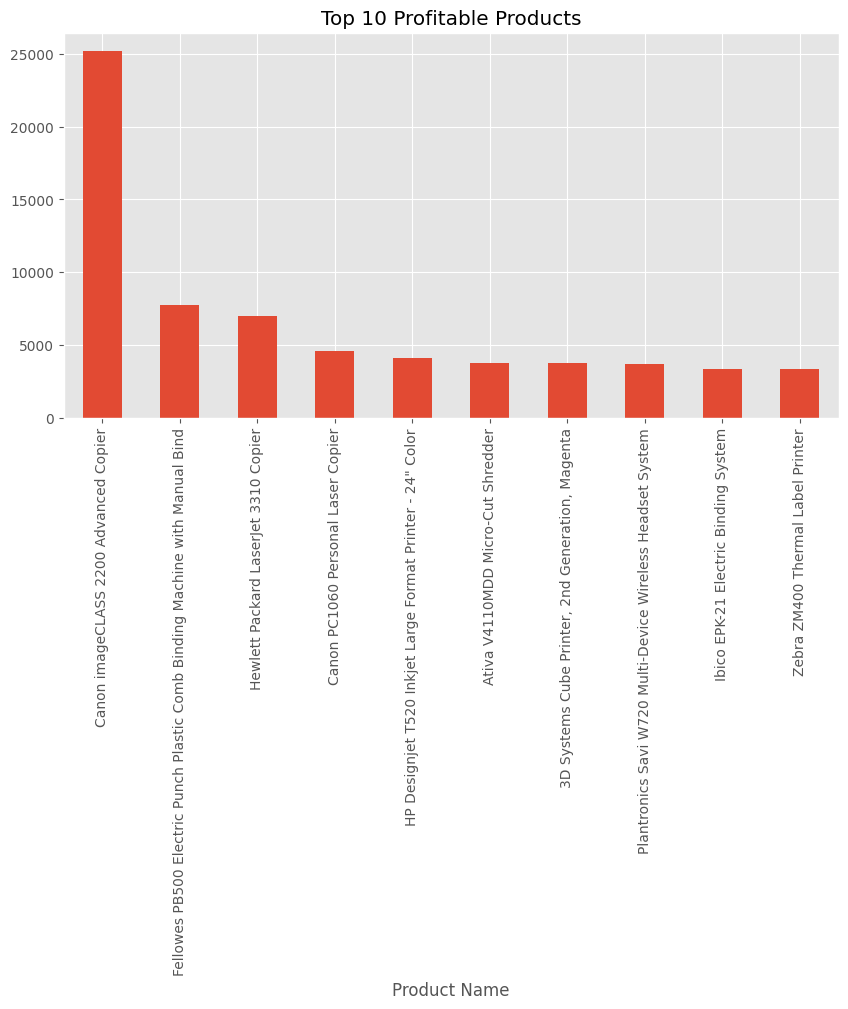

In [22]:
top_profit.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    'Top 10 Profitable Products'
)

plt.show()

In [23]:
df['Order Date'] = pd.to_datetime(
    df['Order Date']
)

In [24]:
df['Month'] = df[
    'Order Date'
].dt.month

In [25]:
monthly_sales = df.groupby(
    'Month'
)['Sales'].sum()

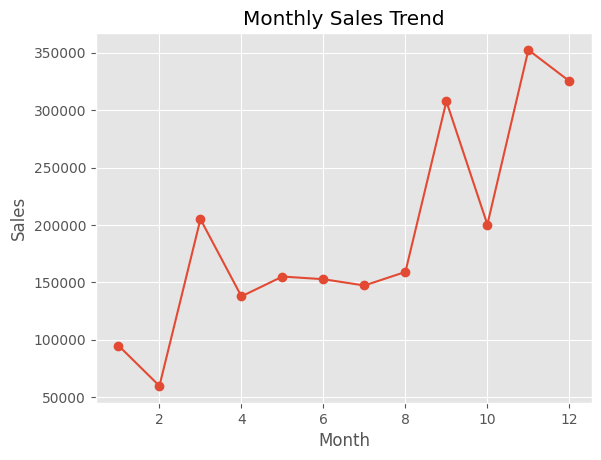

In [26]:
monthly_sales.plot(
    kind='line',
    marker='o'
)

plt.title(
    'Monthly Sales Trend'
)

plt.ylabel('Sales')

plt.show()